In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_excel("swiggy_data.xlsx")

In [3]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [5]:
df.isnull().sum()

State              0
City               0
Order Date         0
Restaurant Name    0
Location           0
Category           0
Dish Name          0
Price (INR)        0
Rating             0
Rating Count       0
dtype: int64

In [6]:
print("no of row:", df.shape[0])

no of row: 197430


In [7]:
print ("No of Fields:", df.shape[1])

No of Fields: 10


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


DATA TYPE

In [9]:
df.dtypes 

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [10]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


 KPI
TOTAL SALES

In [11]:
total_sales = df ["Price (INR)"].sum()
print("Total Sales (INR):",round ( total_sales,2))

Total Sales (INR): 53012505.77


Average Rating

In [12]:
average_rating = df["Rating"].mean()
print ("Average Rating (INR):", round(average_rating,1))

Average Rating (INR): 4.3


Avearge Order value

In [13]:
avg_order_value = df["Price (INR)"].mean()
print("Avg Order Value (INR):", round(avg_order_value,2))

Avg Order Value (INR): 268.51


RATING COUNT

In [14]:
rating_count = df["Rating Count"].sum()
print ("Rating Count:" , round(rating_count,2))

Rating Count: 5591574


TOTAL ORDERS

In [ ]:
total_orders = len(df)
print("Total_Orders:", round(total_orders,2))

CHARTS DESIGN

MONTHLY SALES TREND

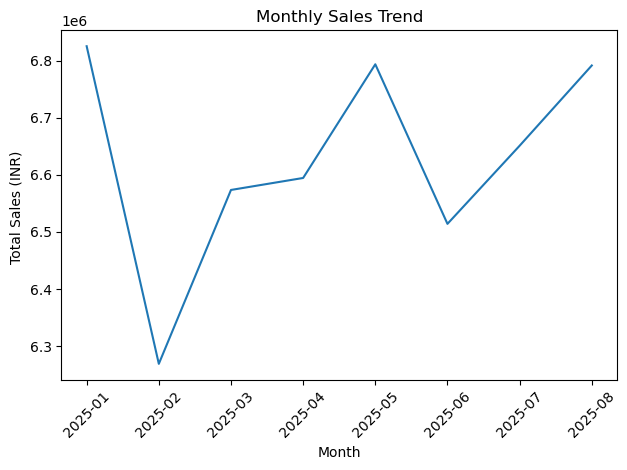

In [16]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales (INR) ")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()

DAILY SALES TREND 

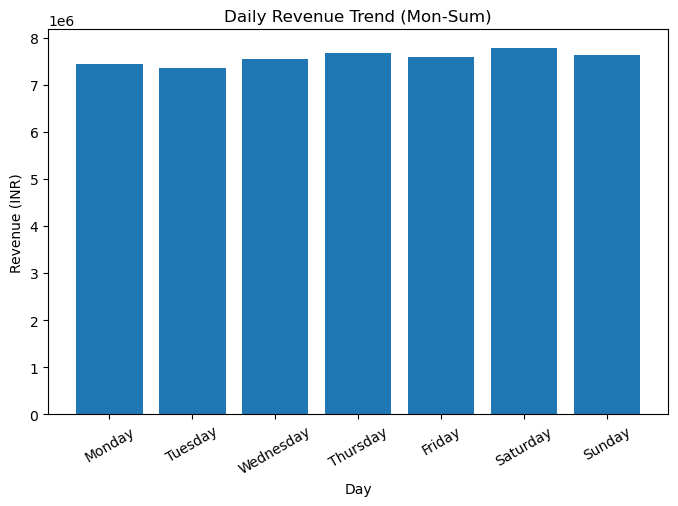

In [21]:
df["DayName"] =pd.to_datetime(df["Order Date"]).dt.day_name()

daily_revenue =(
    df.groupby("DayName")["Price (INR)"]
    .sum()
    .reindex(["Monday", "Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
)

plt.figure(figsize=(8,5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.title("Daily Revenue Trend (Mon-Sum)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)

plt.show()

TOTAL SALES BY FOOD TYPE (VEG VS NON-VEG)

In [22]:
non_veg_keywords =[
    "chicken", "egg", "finish", "mutton",
    "prawan", "biryani", "kabab", "kabab",
    "non-veg", "nonveg"
]
df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg"
)

In [23]:
food_revenue =(
    df.groupby("Food Category")["Price (INR)"]
    .sum()
    .reset_index()
)

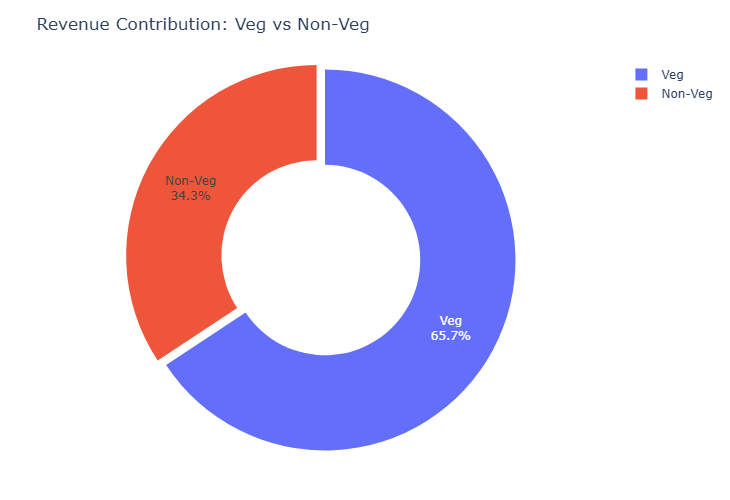

In [24]:
fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food Category",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg",
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05,0]
)
fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40)
)
fig.show()

TOTAL SALES BY STATE

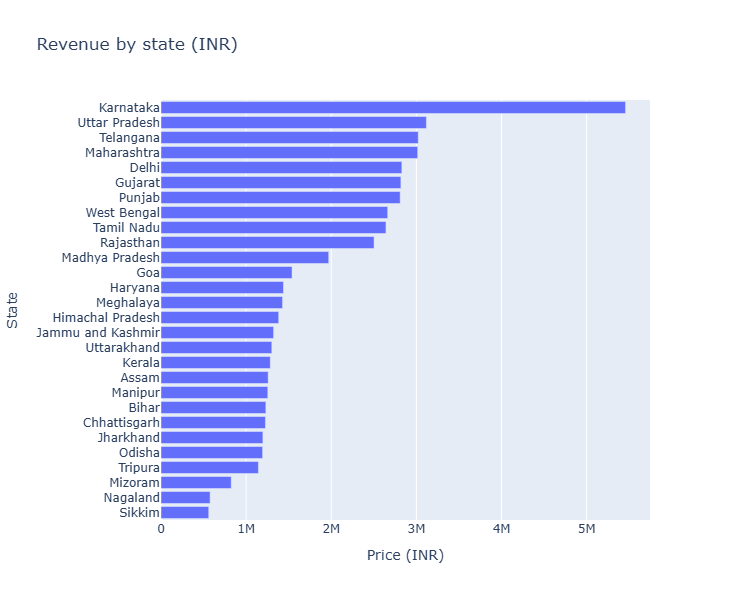

In [17]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
    .sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by state (INR)"
)

fig.update_layout(height=600,yaxis=dict(autorange="reversed"))
fig.show()
                 

QUARTERLY PERFORMANCE SUMMARY

In [19]:
df["Order_Date"]= pd.to_datetime(df["Order Date"])
df["Quarter"]= df["Order_Date"].dt.to_period("Q").astype(str)
quarterly_summary =(
    df.groupby("Quarter", as_index=False)
    .agg(
        Total_Sale=("Price (INR)", "sum"),
        Avg_Ratings=("Rating", "mean"),
        Total_Orders=("Order_Date","count")
    )
    .sort_values("Quarter")
)


quarterly_summary

,Quarter,Total_Sale,Avg_Ratings,Total_Orders
0,2025Q1,19667821.77,4.342643,73096
1,2025Q2,19902256.59,4.340011,74163
2,2025Q3,13442427.41,4.342359,50171


In [ ]:
quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

TOP 5 CITIES BY SALES

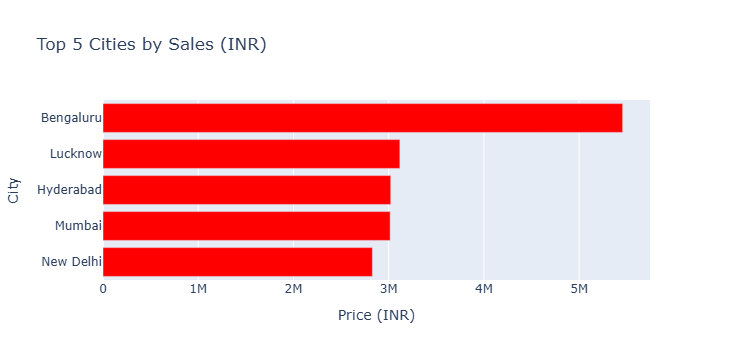

In [18]:
top_5_cities =(
    df.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"]
)
fig.show()
